## HEALPix Sky Coverage

This notebook plots the results of a query to get any combined schedule information from AttitudeChecker. The results are plotted as a HEALPix map, with each observatory represented by a different color (only Rubin is included at the moment). API keys are required and are currently manually generated.

In [ ]:
import sys

import healpy as hp
import httpx
import matplotlib.pyplot as plt
import numpy as np

BASE_URL = "http://127.0.0.1:8000"
API_KEY = "your_api_key"
NUM_HOURS = 24

In [27]:
def grats():
    """Include graticules on mollview plots."""
    try:
        hp.visufunc.delgraticules()
    except AttributeError:
        pass
    hp.visufunc.graticule(dpar=45, dmer=45)

    for i in range(0, 181, 45):
        hp.visufunc.projtext(i, 5, i, lonlat=True)
    for i in range(-180, 0, 45):
        hp.visufunc.projtext(i - 1, 5, i, lonlat=True)
    for i in range(-90, -1, 45):
        hp.visufunc.projtext(0, i, i, lonlat=True)
    for i in range(45, 95, 45):
        hp.visufunc.projtext(0, i - 10, i, lonlat=True)


def fetch_healpix(base_url: str, api_key: str, hours: int) -> dict:
    url = f"{base_url.rstrip('/')}/schedule/healpix"
    response = httpx.get(
        url,
        params={"hours": hours},
        headers={"X-API-Key": api_key},
        timeout=30,
    )
    response.raise_for_status()
    return response.json()


def build_maps(data: dict) -> list[dict]:
    """Return one entry per observatory with its HEALPix map array."""
    entries = []
    for schedule in data["schedules"]:
        nside = schedule["n_side"]
        ordering = schedule["ordering"]  # "nested" or "ring"
        npix = hp.nside2npix(nside)

        sky_map = np.zeros(npix)
        pixel_indices = schedule["pixel_indices"]
        if pixel_indices:
            sky_map[pixel_indices] = 1.0

        # healpy mollview expects RING ordering by default
        if ordering.lower() == "nested":
            sky_map = hp.reorder(sky_map, n2r=True)

        entries.append(
            {
                "name": schedule["observatory_name"],
                "nside": nside,
                "map": sky_map,
                "n_pixels": len(pixel_indices),
            }
        )
    return entries

In [28]:
print(f"Fetching healpix schedule from {BASE_URL} (hours={NUM_HOURS}) …")
data = None

try:
    data = fetch_healpix(BASE_URL, API_KEY, NUM_HOURS)
except httpx.HTTPStatusError as exc:
    print(f"HTTP error: {exc}", file=sys.stderr)
except httpx.ConnectError:
    print(
        f"Could not connect to {BASE_URL}. Is the server running?",
        file=sys.stderr,
    )
if(data):
    print(f"Schedule data received, contains: {data["schedules"][0].keys()}")
    entries = build_maps(data)

Fetching healpix schedule from http://127.0.0.1:8000 (hours=24) …
Schedule data received, contains: dict_keys(['observatory_name', 'observatory_latitude', 'observatory_longitude', 'observatory_elevation', 'schedule_start', 'schedule_end', 'created_at', 'updated_at', 'n_side', 'ordering', 'pixel_indices', 'radius'])


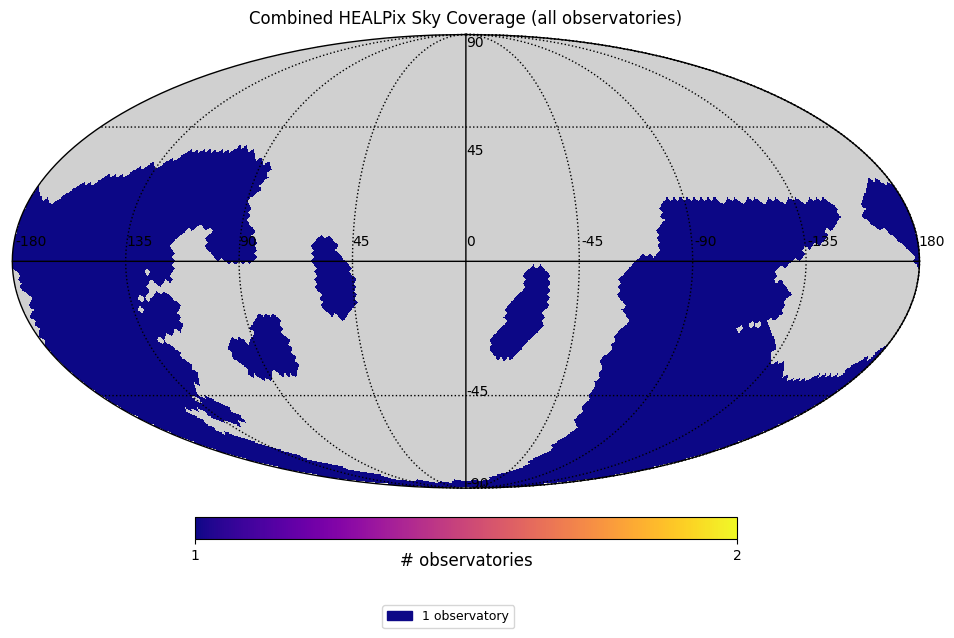

In [ ]:
"""All observatories overlaid on a single Mollweide map using an integer
overlay map: each pixel value encodes which observatory(ies) cover it."""

if not entries:
    print("No observatories returned by the API.")

else:    
    nside = entries[0]["nside"]
    npix = hp.nside2npix(nside)
    overlay = np.zeros(npix)
    for entry in entries:
        overlay += entry["map"]
    overlay_display = np.where(overlay > 0, overlay, hp.UNSEEN)

    plt.figure(figsize=(14, 7))
    hp.mollview(
        overlay_display,
        title="Combined HEALPix Sky Coverage (all observatories)",
        cmap="plasma",
        min=1,
        max=max(len(entries), 2),
        notext=False,
        hold=True,
        bgcolor="white",
        badcolor="#d0d0d0",
        unit="# observatories",
    )
    cmap_plasma = plt.get_cmap("plasma")
    vmin, vmax = 1, max(len(entries), 2)
    legend_handles = [
    plt.Rectangle((0, 0), 1, 1,  # pyright: ignore[reportPrivateImportUsage]
                    color=cmap_plasma((k - vmin) / (vmax - vmin)),
                    label=f"{k} observator{'y' if k == 1 else 'ies'}")
    for k in range(1, len(entries) + 1)
    ]
    
    fig = plt.gcf()
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=min(len(entries), 4),
        fontsize=9,
        framealpha=0.8,
    )
    grats()
    plt.show()